<a href="https://colab.research.google.com/github/jaanuyadav1020-stack/medimind/blob/main/miniproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
# Load the dataset
df = pd.read_csv('/content/sample_data/archive(4).zip')




In [4]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [5]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
features = ['bedrooms', 'bathrooms', 'area', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea','furnishingstatus']

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder



label_encoder = LabelEncoder()
df['mainroad'] = label_encoder.fit_transform(df['mainroad'])
print(df)

        price  area  bedrooms  bathrooms  stories  mainroad guestroom  \
0    13300000  7420         4          2        3         1        no   
1    12250000  8960         4          4        4         1        no   
2    12250000  9960         3          2        2         1        no   
3    12215000  7500         4          2        2         1        no   
4    11410000  7420         4          1        2         1       yes   
..        ...   ...       ...        ...      ...       ...       ...   
540   1820000  3000         2          1        1         1        no   
541   1767150  2400         3          1        1         0        no   
542   1750000  3620         2          1        1         1        no   
543   1750000  2910         3          1        1         0        no   
544   1750000  3850         3          1        2         1        no   

    basement hotwaterheating airconditioning  parking prefarea  \
0         no              no             yes        2    

In [15]:
df['guestroom'] = label_encoder.fit_transform(df['guestroom'])
df['basement'] = label_encoder.fit_transform(df['basement'])
df['hotwaterheating'] = label_encoder.fit_transform(df['hotwaterheating'])
df['airconditioning'] = label_encoder.fit_transform(df['airconditioning'])

In [17]:
df['prefarea'] = label_encoder.fit_transform(df['prefarea'])
df['furnishingstatus'] = label_encoder.fit_transform(df['furnishingstatus'])

In [18]:
X=df[features]
y=df['price']

In [19]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [20]:
# Predict prices
y_pred = model.predict(X_test)

# Evaluate R² score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")


R² Score: 0.6495


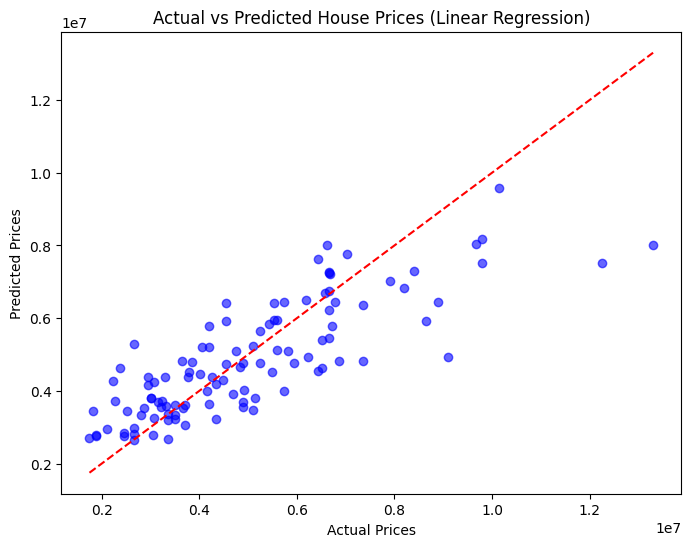

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices (Linear Regression)')
plt.show()
